In [33]:
import pandas as pd
import numpy as np

# データ本体(センサー測定値)
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
df_data = pd.read_csv(data_url, sep=' ', header=None)

# ラベル(Pass/Fail + タイムスタンプ)
labels_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"
df_labels = pd.read_csv(labels_url, sep=' ', header=None, names=['label', 'timestamp'])

print(df_data.shape)
print(df_labels.shape)
df_data.head()

(1567, 590)
(1567, 2)


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [34]:
#欠損値の数を列ごとに集計し、多い順に　上位10列を表示
missing_counts = df_data.isnull().sum()
missing_counts.sort_values(ascending=False).head(10)

292    1429
293    1429
158    1429
157    1429
492    1341
85     1341
358    1341
220    1341
244    1018
517    1018
dtype: int64

In [35]:
#　欠損率を計算(0~1の比率　)
missing_rate=df_data.isnull().sum()/len(df_data)

#欠損率50%未満列のみ残す
threshold=0.5
df_clean=df_data.loc[:, missing_rate<threshold]

print(f"処理前:{df_data.shape}")
print(f"処理後:{df_clean.shape}")
print(f"削除した列数:{df_data.shape[1]-df_clean.shape[1]}")

処理前:(1567, 590)
処理後:(1567, 562)
削除した列数:28


In [36]:
#df_dataにlabelとtimestampを列として追加
df=df_clean.copy()
df['label']=df_labels['label']
df['timestamp']=df_labels['timestamp']

print(df.shape)
df[['label', 'timestamp']].head()

(1567, 564)


,label,timestamp
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [37]:
#Pass/Fail件数と比率

In [38]:
label_counts=df['label'].value_counts()
label_ratio= df['label'].value_counts(normalize=True)*100

print("件数:")
print(label_counts)
print("\n比率(%):")
print(label_ratio.round(1))

件数:
label
-1    1463
 1     104
Name: count, dtype: int64

比率(%):
label
-1    93.4
 1     6.6
Name: proportion, dtype: float64


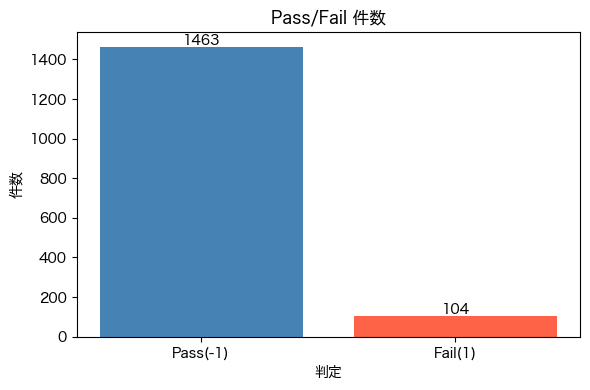

In [39]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Hiragino Sans')

#Pass/Fail棒グラフ
fig, ax=plt.subplots(figsize=(6,4))
ax.bar(['Pass(-1)', 'Fail(1)'], label_counts.values, color=['steelblue', 'tomato'])
ax.set_title('Pass/Fail 件数')
ax.set_xlabel('判定')
ax.set_ylabel('件数')

for i, v in enumerate(label_counts.values):
    ax.text(i, v+10, str(v), ha='center')

plt.tight_layout()
plt.show()

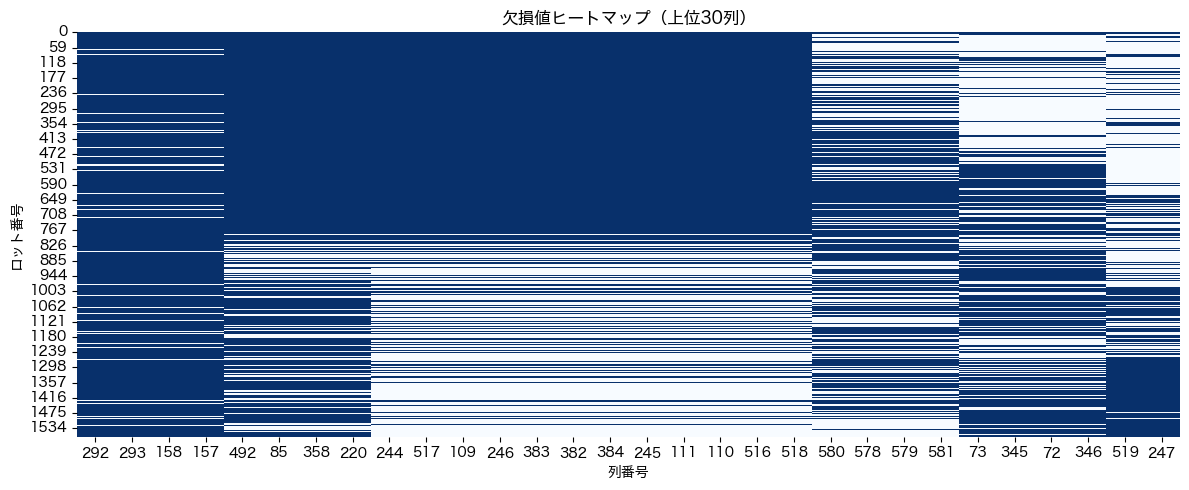

In [40]:
import seaborn as sns

#欠損率上位30列を抽出
top30_cols=missing_rate.sort_values(ascending=False).head(30).index
df_missing_top30=df_data[top30_cols].isnull()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df_missing_top30, cmap='Blues', cbar=False, ax=ax)
ax.set_title('欠損値ヒートマップ（上位30列）')
ax.set_xlabel('列番号')
ax.set_ylabel('ロット番号')
plt.tight_layout()
plt.show()

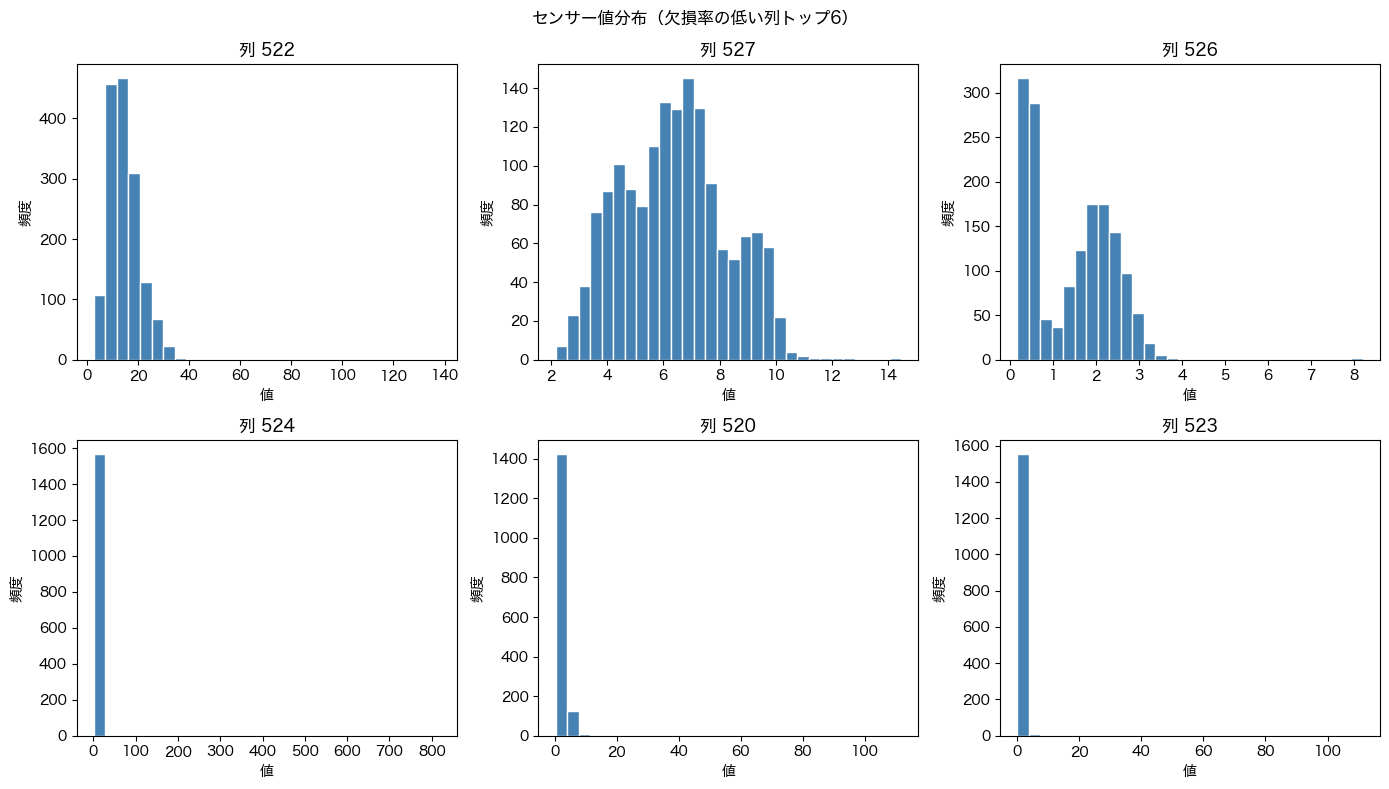

In [41]:
# 欠損率の低い列トップ6を抽出
low_missing_cols = missing_rate.sort_values().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(low_missing_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'列 {col}')
    axes[i].set_xlabel('値')
    axes[i].set_ylabel('頻度')

plt.suptitle('センサー値分布（欠損率の低い列トップ6）')
plt.tight_layout()
plt.show()

In [44]:
df_clean.columns.tolist()

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 190,
 191,
 19

In [45]:
df_clean.shape

(1567, 562)

In [46]:
# labelとtimestampがどの変数に入っているか確認
print(df_labels.head(2))

   label            timestamp
0     -1  19/07/2008 11:55:00
1     -1  19/07/2008 12:32:00


In [47]:
df_clean = pd.concat([df_clean, df_labels], axis=1)
df_clean.shape

(1567, 564)

In [48]:
variance = df_clean.drop(columns=['label', 'timestamp']).var()
variance.sort_values().head(10)

450    0.0
451    0.0
449    0.0
414    0.0
404    0.0
403    0.0
402    0.0
5      0.0
381    0.0
422    0.0
dtype: float64

In [53]:
const_cols=variance[variance==0].index.tolist()
print(f"分散0の列数:{len(const_cols)}")
print(const_cols)

分散0の列数:116
[5, 13, 42, 49, 52, 69, 97, 141, 149, 178, 179, 186, 189, 190, 191, 192, 193, 194, 226, 229, 230, 231, 232, 233, 234, 235, 236, 237, 240, 241, 242, 243, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 276, 284, 313, 314, 315, 322, 325, 326, 327, 328, 329, 330, 364, 369, 370, 371, 372, 373, 374, 375, 378, 379, 380, 381, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 414, 422, 449, 450, 451, 458, 461, 462, 463, 464, 465, 466, 481, 498, 501, 502, 503, 504, 505, 506, 507, 508, 509, 512, 513, 514, 515, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538]


In [54]:
print(520 in const_cols, 523 in const_cols, 524 in const_cols)

False False False


In [55]:
df_model=df_clean.drop(columns=const_cols)
df_model.shape

(1567, 448)

In [60]:
variance_model=df_model.drop(columns=['label', 'timestamp']).var()
variance_model.sort_values().head(30)

95     1.090102e-08
94     3.032293e-08
101    4.873603e-08
544    8.733216e-08
278    1.156231e-07
100    1.264063e-07
377    2.176596e-07
357    2.509253e-07
376    2.855300e-07
104    7.237052e-07
143    1.643035e-06
239    2.077649e-06
543    2.351759e-06
219    2.709667e-06
114    2.782538e-06
238    2.883027e-06
368    4.438111e-06
131    5.065094e-06
366    5.676064e-06
365    7.054390e-06
367    7.285036e-06
542    7.489852e-06
588    8.220099e-06
288    8.620656e-06
392    8.735296e-06
106    8.927623e-06
93     9.059099e-06
103    9.391460e-06
105    1.025491e-05
92     1.043952e-05
dtype: float64

In [61]:
df_model[95].describe()

count    1561.000000
mean        0.000060
std         0.000104
min        -0.000900
25%         0.000000
50%         0.000000
75%         0.000100
max         0.000900
Name: 95, dtype: float64

In [62]:
df_pass=df_model[df_model['label']==-1]
df_fail=df_model[df_model['label']==1]
print(df_pass.shape, df_fail.shape)

(1463, 448) (104, 448)


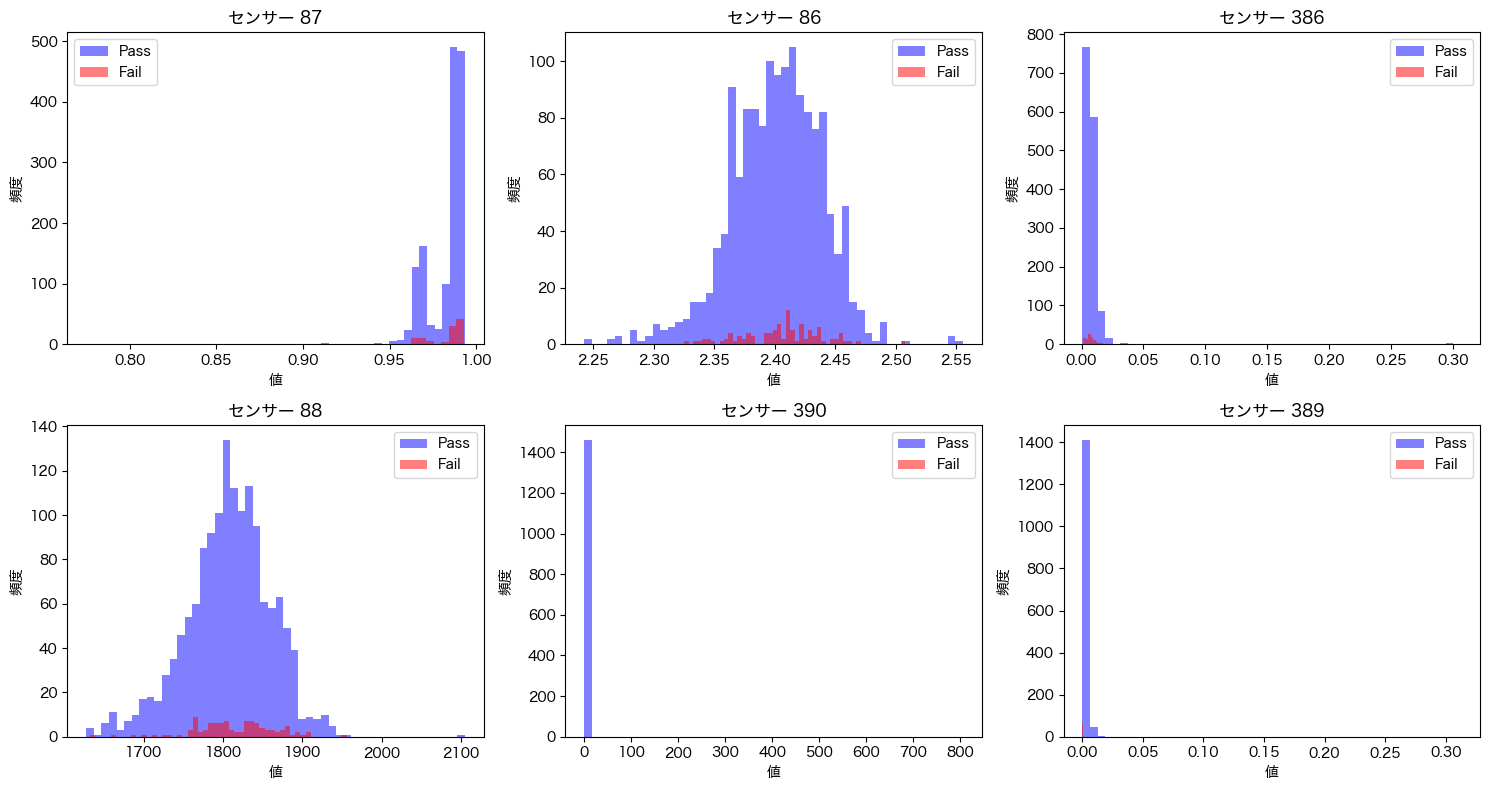

In [65]:
#欠損率が低い順に6列選ぶ（labelとtimestampを除く）
sonsor_cols=df_model.drop(columns=['label', 'timestamp']).columns
missing_rate_model=df_model[sonsor_cols].isnull().mean()
plot_cols=missing_rate_model.sort_values().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df_pass[col].dropna(), bins=50, alpha=0.5, label='Pass', color='blue')
    axes[i].hist(df_fail[col].dropna(), bins=50, alpha=0.5, label='Fail', color='red')
    axes[i].set_title(f'センサー {col}')
    axes[i].set_xlabel('値')
    axes[i].set_ylabel('頻度')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [66]:
mean_pass = df_pass.drop(columns=['label', 'timestamp']).mean()
mean_fail = df_fail.drop(columns=['label', 'timestamp']).mean()

relative_diff = (abs(mean_fail - mean_pass) / abs(mean_pass))
relative_diff = relative_diff.replace([float('inf')], float('nan'))  # 0除算対策

relative_diff.sort_values(ascending=False).head(10)

104    22.799095
10     20.164740
99     15.335926
102     5.925529
249     5.358188
387     5.292564
114     4.998986
101     3.836653
107     3.793104
67      3.618812
dtype: float64

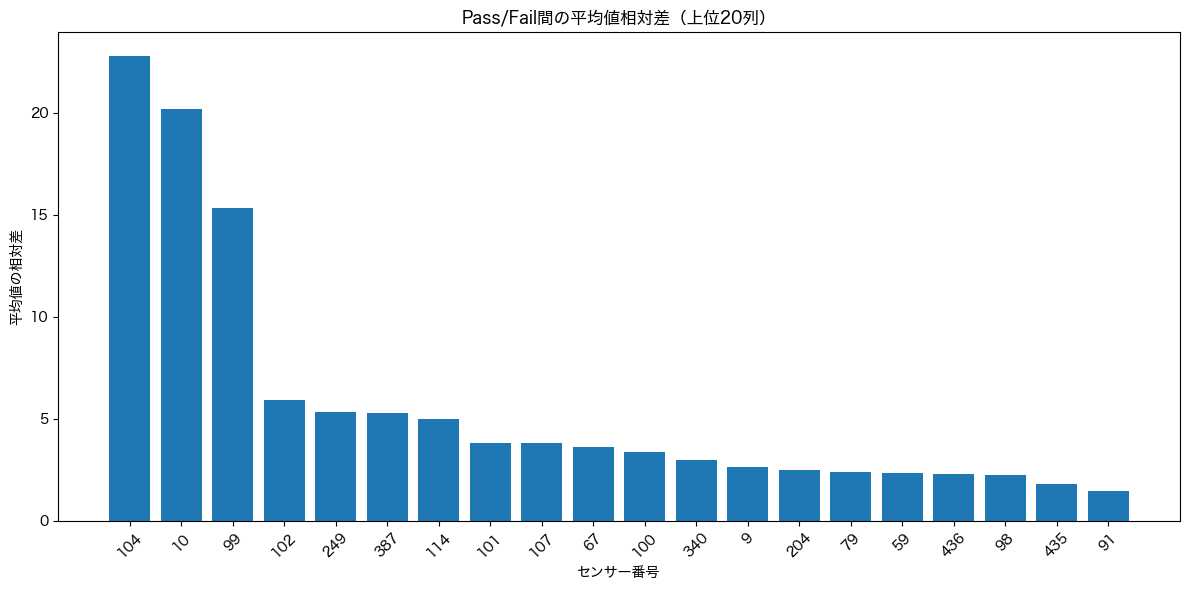

In [67]:
top20 = relative_diff.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(top20)), top20.values)
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45)
ax.set_xlabel('センサー番号')
ax.set_ylabel('平均値の相対差')
ax.set_title('Pass/Fail間の平均値相対差（上位20列）')
plt.tight_layout()
plt.show()

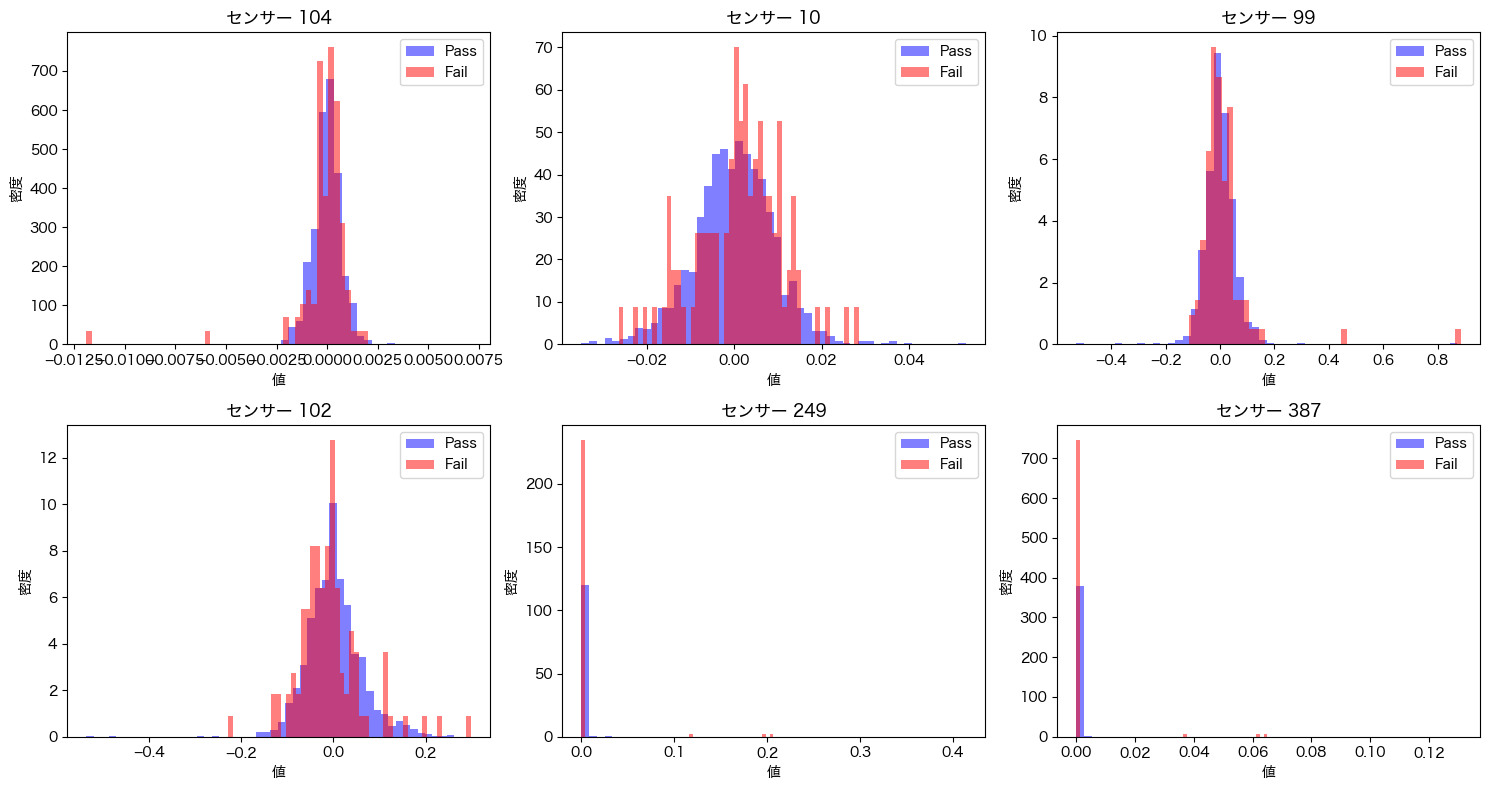

In [69]:
top6_cols = relative_diff.sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top6_cols):
    axes[i].hist(df_pass[col].dropna(), bins=50, alpha=0.5,
                 label='Pass', color='blue', density=True)
    axes[i].hist(df_fail[col].dropna(), bins=50, alpha=0.5,
                 label='Fail', color='red', density=True)
    axes[i].set_title(f'センサー {col}')
    axes[i].set_xlabel('値')
    axes[i].set_ylabel('密度')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [70]:
df_raw = pd.concat([df_data, df_labels['label']], axis=1)

df_raw_pass = df_raw[df_raw['label'] == -1]
df_raw_fail = df_raw[df_raw['label'] == 1]

missing_pass_raw = df_raw_pass.drop(columns=['label']).isnull().mean()
missing_fail_raw = df_raw_fail.drop(columns=['label']).isnull().mean()

missing_diff_raw = (missing_fail_raw - missing_pass_raw).sort_values(ascending=False)
missing_diff_raw.head(10)

517    0.066289
516    0.066289
518    0.066289
246    0.066289
244    0.066289
382    0.066289
383    0.066289
111    0.066289
110    0.066289
109    0.066289
dtype: float64

In [73]:
#Failサンプルの全列欠損行を確認
fail_all_missing=df_raw_fail.drop(columns=['label']).isnull().all(axis=1)
print(f"全列欠損のFailサンプル数:{fail_all_missing.sum()}")

全列欠損のFailサンプル数:0


In [74]:
# Failサンプルで欠損率が高い列上位10件
missing_fail_raw.sort_values(ascending=False).head(10)

293    0.923077
292    0.923077
157    0.923077
158    0.923077
85     0.894231
220    0.894231
358    0.894231
492    0.894231
246    0.711538
245    0.711538
dtype: float64

In [75]:
print(missing_pass_raw[[293, 292, 157, 158]])

293    0.911141
292    0.911141
157    0.911141
158    0.911141
dtype: float64
